In [1]:
import json
from datetime import datetime
from pprint import pprint

timelines = {"train": {}, "dev": {}}
for site in ['breast', 'melanoma', 'ovarian']:
    for split in timelines:
        with open(f'chemoTimelines2024_train_dev_labeled/subtask1/Gold_Timelines_allPatients/{site}_{split}_all_patients_gold_timelines.json') as f:
            new_data = json.load(f)
        timelines[split].update({f"{site}_{key}": sorted(value) for key, value in new_data.items()})
len(timelines['train']), len(timelines['dev'])

(69, 27)

In [2]:
def summarize_timelines(timelines):
    """Summarize the timelines to count unique treatments, tags, and dates."""
    items = []
    treatments = set()
    tags = set()
    dates = set()

    for split in timelines:
        for key, value in timelines[split].items():
            for item in value:
                items.append(item)
                treatments.add(item[0])
                tags.add(item[1])
                dates.add(item[2])

    print(f"Items: {len(items)}")
    print(f"Treatments: {len(treatments)}")
    print(f"Tags: {len(tags)}")
    print(f"Dates: {len(dates)}")
    
summarize_timelines(timelines)

Items: 446
Treatments: 47
Tags: 3
Dates: 241


In [3]:
# # rename "chemo" to "chemotherapy" and remove duplicates
# for split in timelines:
#     for key, value in timelines[split].items():
#         for item in value:
#             if "chemo" == item[0].lower():
#                 item[0] = "chemotherapy"
#         timelines[split][key] = list({tuple(i) for i in value})
#         timelines[split][key].sort(key=lambda x: (x[2], x[0], x[1]))

# summarize_timelines(timelines)

In [4]:
pprint(timelines)

{'dev': {'breast_patient01': [['carboplatin', 'begins-on', '2011-12-27'],
                              ['carboplatin', 'ends-on', '2012-04-10'],
                              ['chemotherapy', 'contains-1', '2011'],
                              ['chemotherapy', 'ends-on', '2012-04-11'],
                              ['herceptin', 'begins-on', '2011-12-27'],
                              ['herceptin', 'begins-on', '2012-05-01'],
                              ['herceptin', 'contains-1', '2012-06-05'],
                              ['herceptin', 'contains-1', '2012-06-11'],
                              ['herceptin', 'ends-on', '2012-04-10'],
                              ['taxotere', 'begins-on', '2011-12-27'],
                              ['taxotere', 'ends-on', '2012-04-10'],
                              ['tch', 'begins-on', '2011-12-27'],
                              ['tch', 'ends-on', '2012-04-10']],
         'breast_patient02': [['abraxane', 'ends-on', '2012-08-01'],
           

In [5]:
# Save the timeline files in a new folder
import os
output_dir = 'chemoTimelines2024_train_dev_labeled/subtask1/Gold_Timelines_allPatients_processed'
os.makedirs(output_dir, exist_ok=True)
for split in timelines:
    for key, value in timelines[split].items():
        with open(os.path.join(output_dir, f"{split}_{key}.json"), 'w') as f:
            json.dump(value, f, indent=2)

In [6]:
week_dates = set()
no_day = set()
no_month = set()

for split in timelines:
    for key, value in timelines[split].items():
        for item in value:
            if "w" in item[2]:
                week_dates.add(f"{key} ({split})")
            elif len(item[2]) == 7:
                no_day.add(f"{key} ({split})")
            elif len(item[2]) == 4:
                no_month.add(f"{key} ({split})")
            else:
                try:
                    date = datetime.strptime(item[2], "%Y-%m-%d")
                except ValueError:
                    print(f"Invalid date format: {item[2]} in {key} ({split})")

pprint((week_dates & no_day) | (week_dates & no_month) | (no_day & no_month))

{'breast_patient27 (train)',
 'breast_patient41 (train)',
 'ovarian_patient19 (dev)',
 'ovarian_patient38 (train)',
 'ovarian_patient48 (train)'}


In [7]:
timelines['train']['breast_patient41']

[['chemotherapy', 'begins-on', '2013-w32'],
 ['chemotherapy', 'contains-1', '2013-08-10'],
 ['cyclophosphamide', 'begins-on', '2013-08-08'],
 ['cyclophosphamide', 'ends-on', '2013-10-10'],
 ['cytoxan', 'begins-on', '2013-08-08'],
 ['cytoxan', 'contains-1', '2013-08-29'],
 ['cytoxan', 'contains-1', '2013-09-19'],
 ['cytoxan', 'contains-1', '2013-10-10'],
 ['docetaxel', 'begins-on', '2013-08-08'],
 ['docetaxel', 'ends-on', '2013-10-10'],
 ['docetaxol', 'begins-on', '2013-08-08'],
 ['taxotere', 'begins-on', '2013-08-08'],
 ['taxotere', 'contains-1', '2013-08-29'],
 ['taxotere', 'contains-1', '2013-09-19'],
 ['taxotere', 'contains-1', '2013-10-10'],
 ['tc', 'contains-1', '2013-08']]

In [8]:
from matplotlib import pyplot as plt
from seaborn import kdeplot
import numpy as np
import tiktoken

tokenizer = tiktoken.get_encoding("cl100k_base")

def plot_token_lengths(data, suffix=""):
    lengths_train = {k: [len(tokenizer.encode(x)) for x in v] for k, v in data['train']['chunks'].items()}
    lengths_dev = {k: [len(tokenizer.encode(x)) for x in v] for k, v in data['dev']['chunks'].items()}
    breast_lengths_train = {k: v for k, v in lengths_train.items() if k.startswith('breast')}
    breast_lengths_dev = {k: v for k, v in lengths_dev.items() if k.startswith('breast')}
    melanoma_lengths_train = {k: v for k, v in lengths_train.items() if k.startswith('melanoma')}
    melanoma_lengths_dev = {k: v for k, v in lengths_dev.items() if k.startswith('melanoma')}
    ovarian_lengths_train = {k: v for k, v in lengths_train.items() if k.startswith('ovarian')}
    ovarian_lengths_dev = {k: v for k, v in lengths_dev.items() if k.startswith('ovarian')}
    print("Mean token length in train:", np.mean([x for v in lengths_train.values() for x in v]))
    print("Mean token length in dev:", np.mean([x for v in lengths_dev.values() for x in v]))
    print("Median token length in train:", np.median([x for v in lengths_train.values() for x in v]))
    print("Median token length in dev:", np.median([x for v in lengths_dev.values() for x in v]))
    print("Max token length in train:", max(max(v) for k, v in lengths_train.items()))
    print("Max token length in dev:", max(max(v) for k, v in lengths_dev.items()))
    print("Sum token length in train:", sum(sum(v) for k, v in lengths_train.items()))
    print("Sum token length in dev:", sum(sum(v) for k, v in lengths_dev.items()))
    def plot_histogram(lengths_train, lengths_dev, title):
        # aggregated
        plt.figure(figsize=(10, 5))
        plt.hist([x for v in lengths_train.values() for x in v], 
                 bins=100, alpha=0.5, density=True, label='Train', color='blue')
        plt.hist([x for v in lengths_dev.values() for x in v], 
                 bins=100, alpha=0.5, density=True, label='Dev', color='orange')
        plt.legend(["Train", "Dev"])
        plt.xlabel("Number of tokens in report")
        plt.ylabel("Density of reports (aggregated)")
        plt.title(title + " Token Length Distribution" + suffix)
        plt.show()
        # per patient
        plt.figure(figsize=(10, 5))
        plt.bar([k for k in lengths_train.keys()],
                [sum(v) for v in lengths_train.values()],
                alpha=0.5, label='Train', color='blue')
        plt.bar([k for k in lengths_dev.keys()],
                [sum(v) for v in lengths_dev.values()],
                alpha=0.5, label='Dev', color='orange')
        plt.xticks(rotation=90)
        plt.xlabel("Patient")
        plt.ylabel("Tokens per patient")
        plt.title(title + " Sum Token Length per Patient" + suffix)
        plt.legend()
        plt.show()
    plot_histogram(breast_lengths_train, breast_lengths_dev, "Breast Cancer")
    plot_histogram(melanoma_lengths_train, melanoma_lengths_dev, "Melanoma")
    plot_histogram(ovarian_lengths_train, ovarian_lengths_dev, "Ovarian Cancer")
    plot_histogram(lengths_train, lengths_dev, "All Cancer Types")

Mean token length in train: 1335.6082474226805
Mean token length in dev: 1196.127358490566
Median token length in train: 915.5
Median token length in dev: 938.5
Max token length in train: 6699
Max token length in dev: 11060
Sum token length in train: 3886620
Sum token length in dev: 1521474


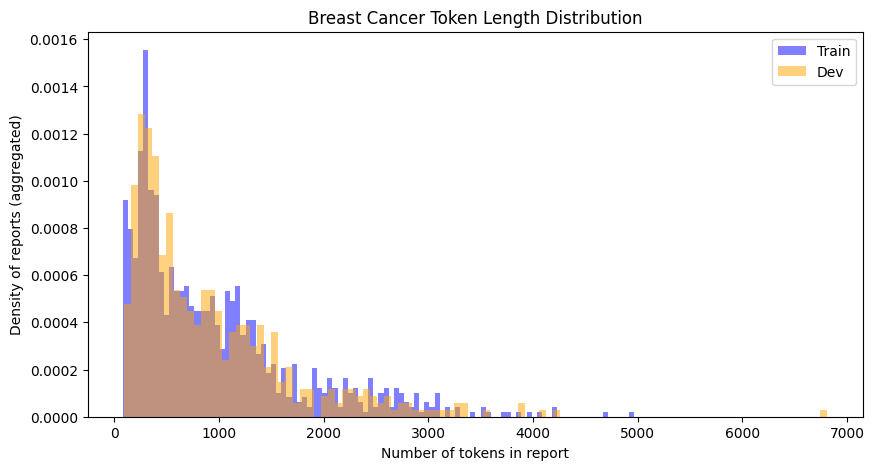

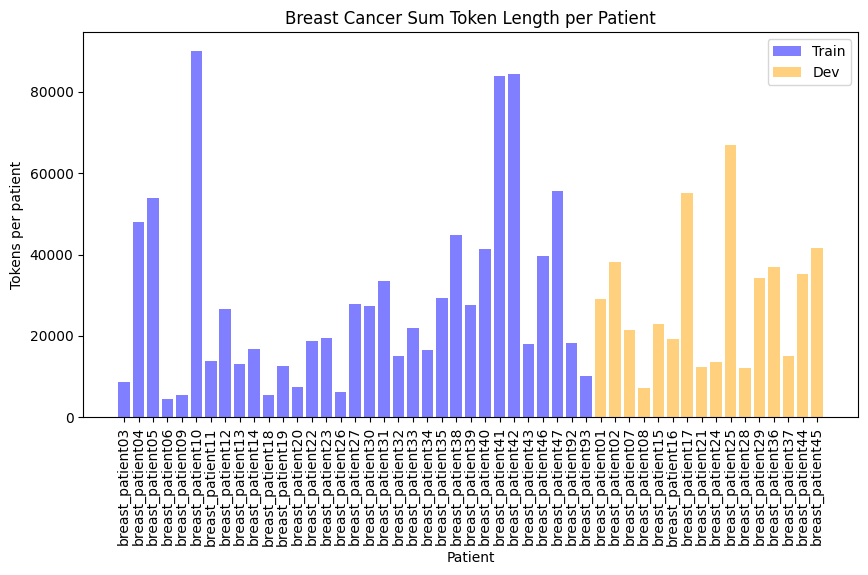

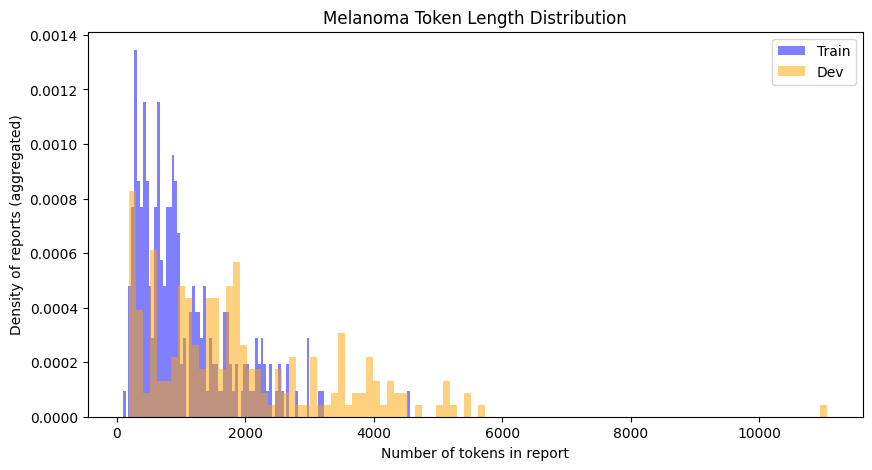

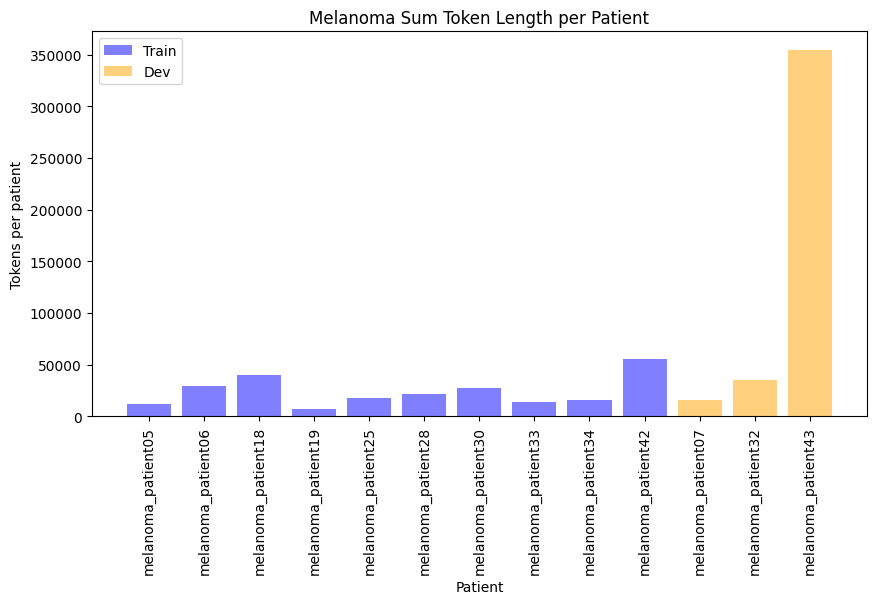

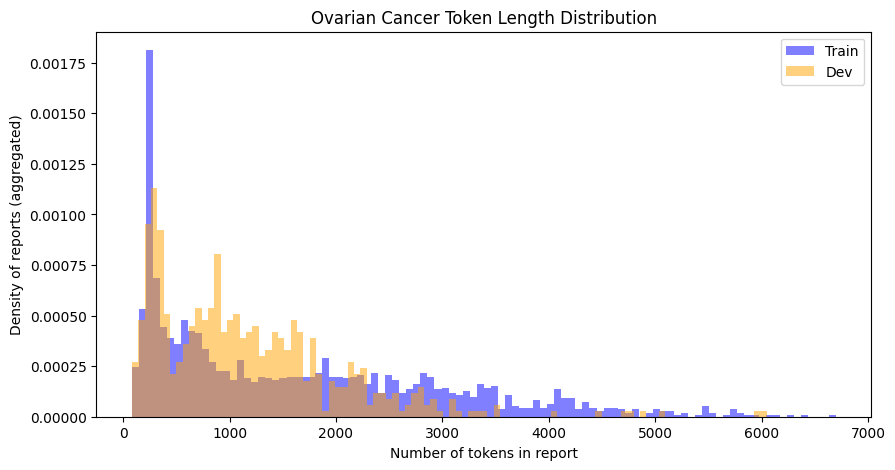

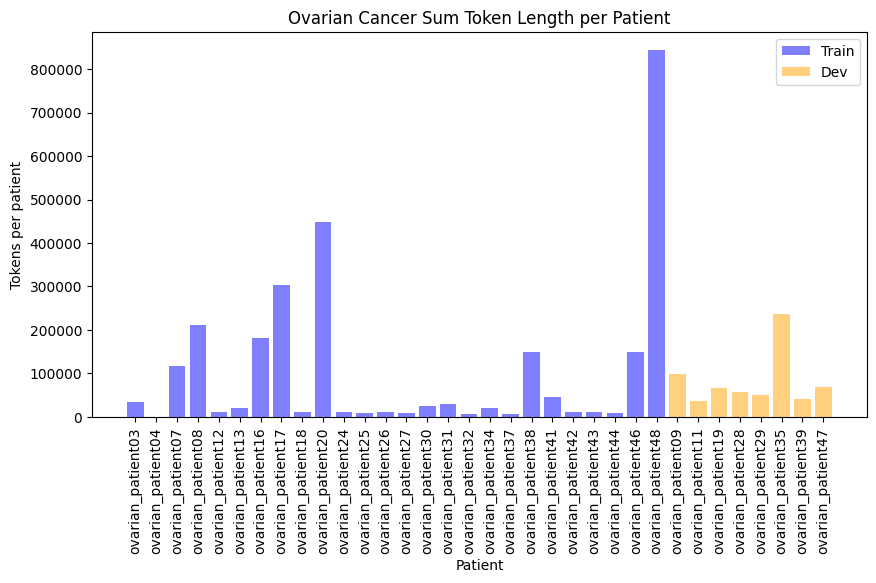

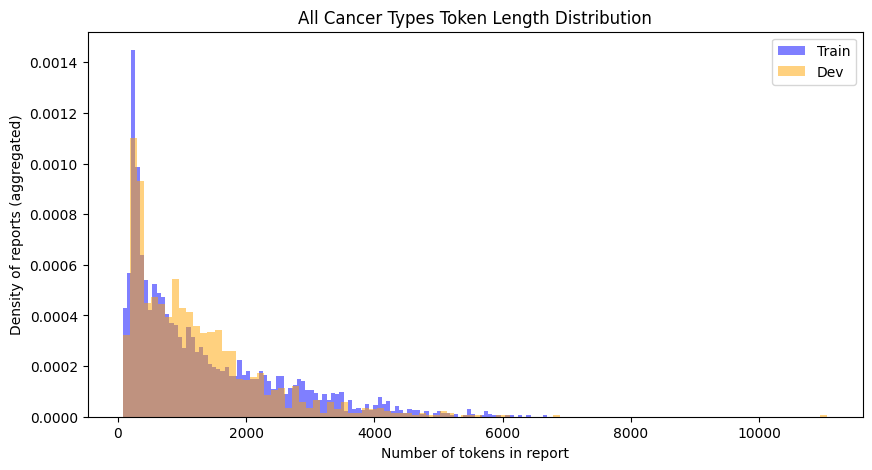

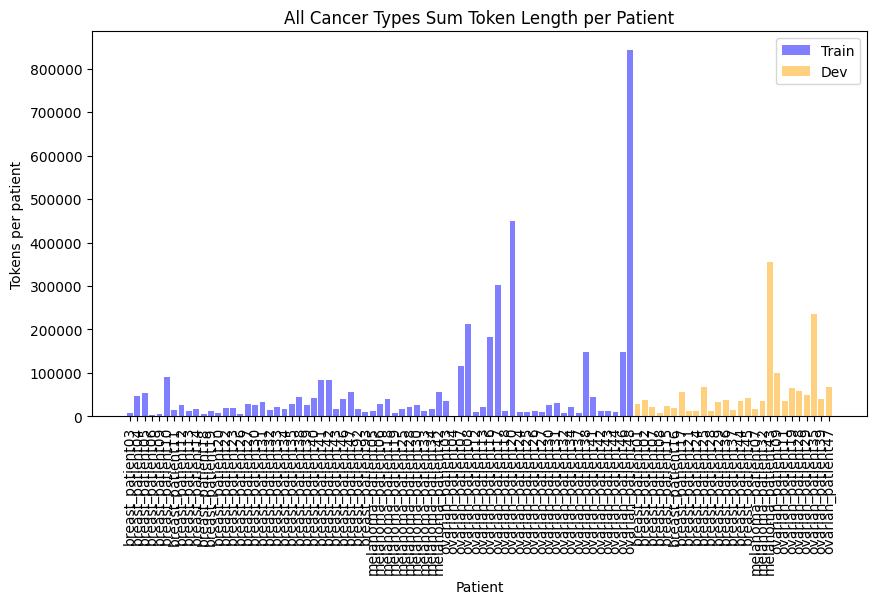

Mean token length in train: 24607.803797468354
Mean token length in dev: 23417.138461538463
Median token length in train: 29656.0
Median token length in dev: 30376.0
Max token length in train: 31988
Max token length in dev: 31968
Sum token length in train: 3888033
Sum token length in dev: 1522114


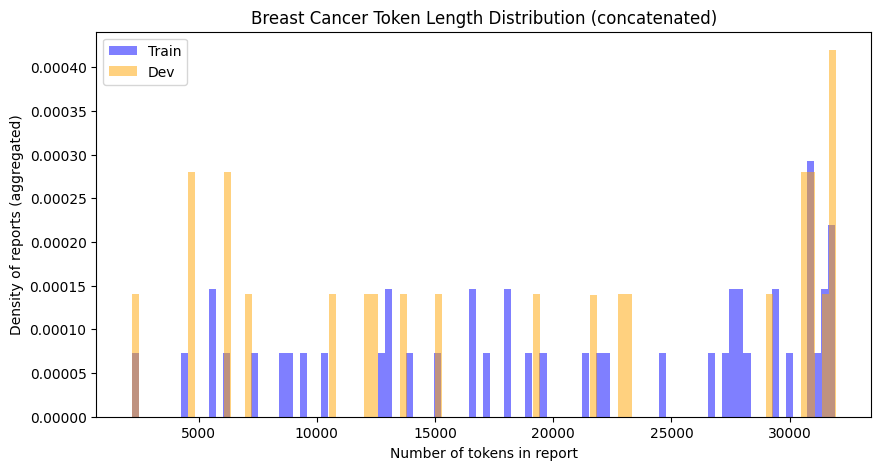

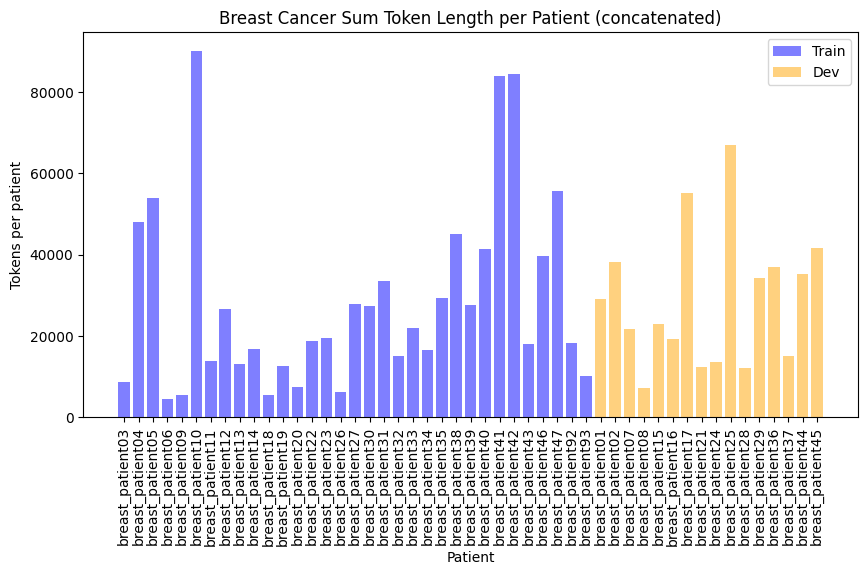

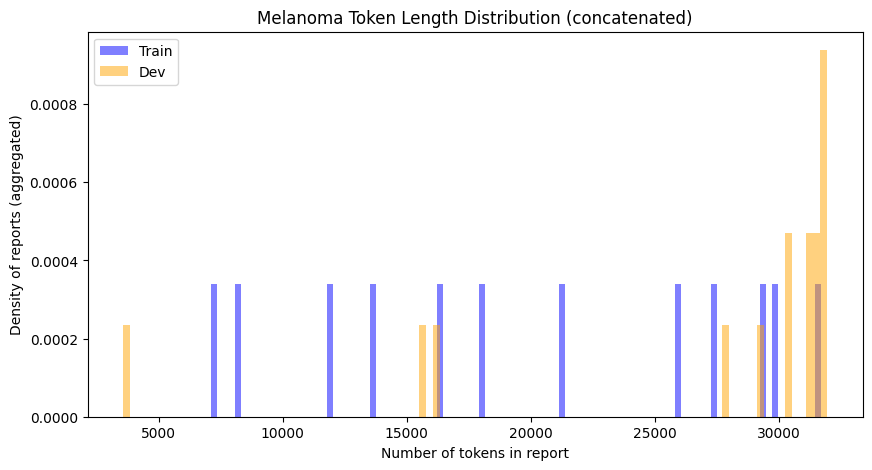

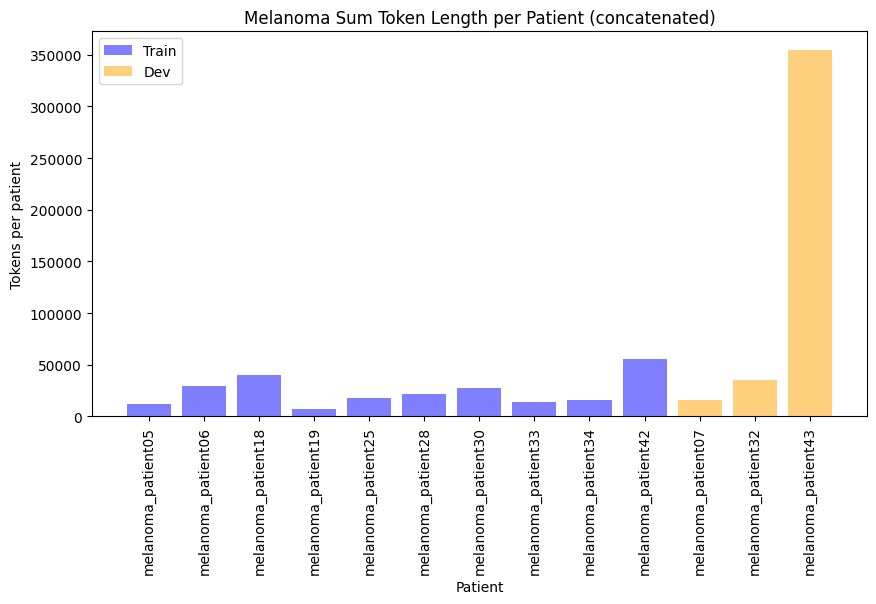

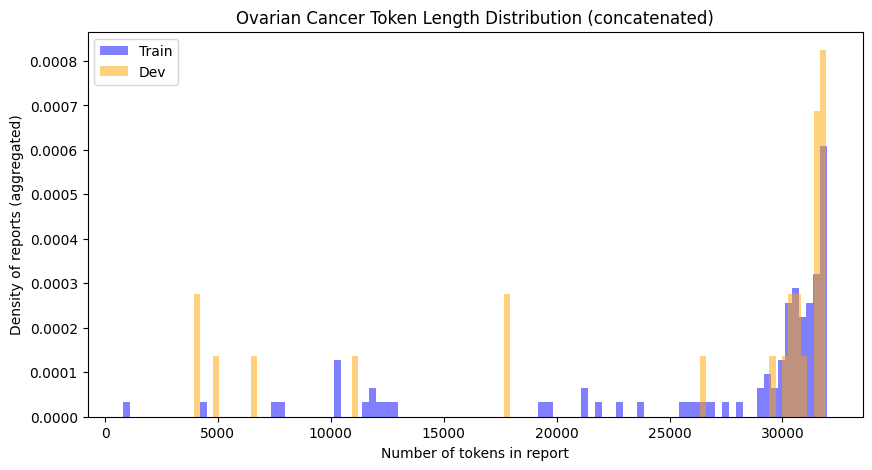

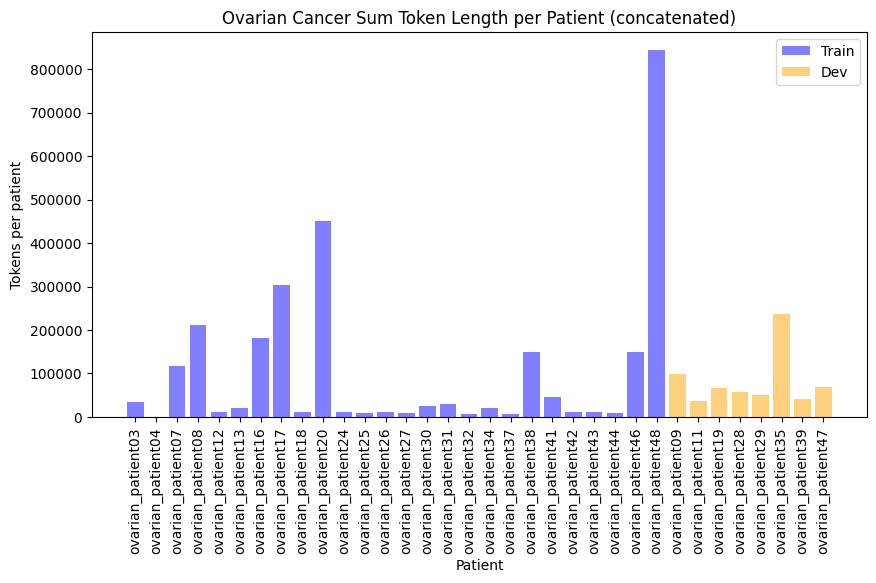

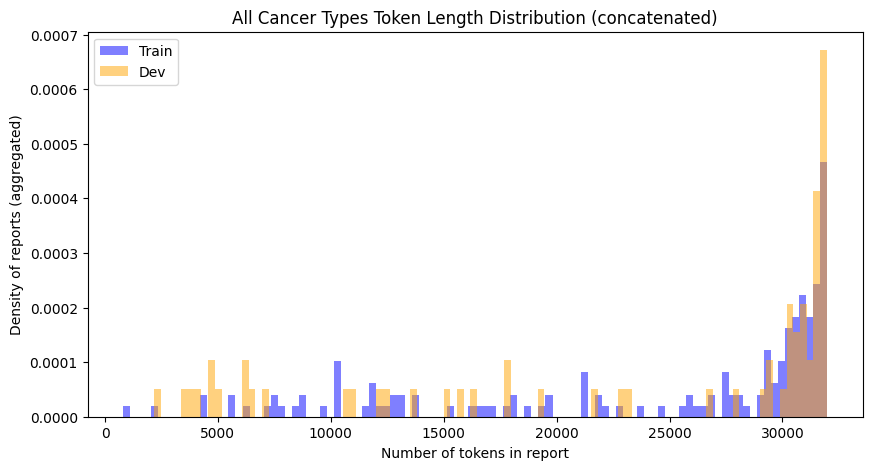

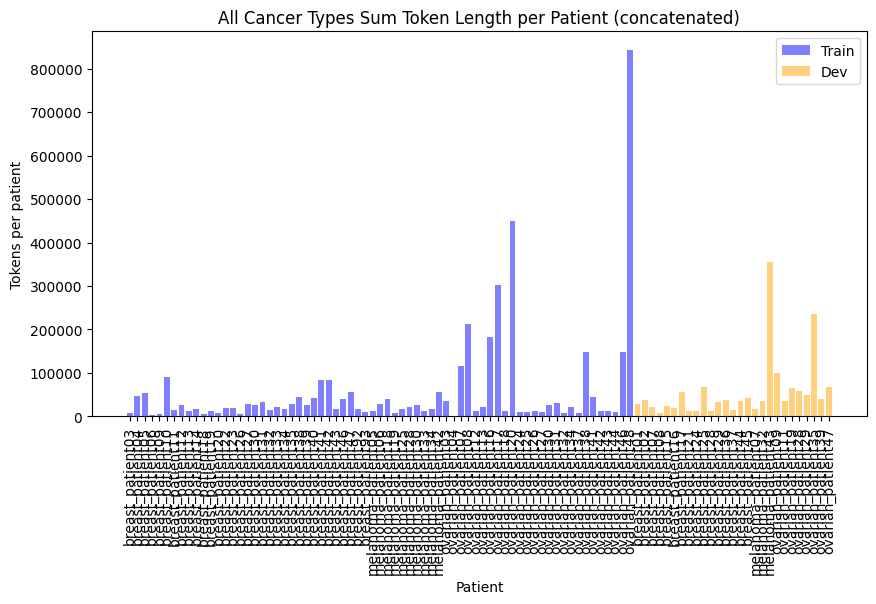

In [9]:
import json
import os
from collections import defaultdict

data = {split: {"chunks": defaultdict(list), "timeline": {}} for split in ["train", "dev"]}
notes_path = "chemoTimelines2024_train_dev_labeled/subtask1/Patient_Notes"
timelines_path = "chemoTimelines2024_train_dev_labeled/subtask1/Gold_Timelines_allPatients"

for split in data:
    for site in ["breast", "melanoma", "ovarian"]:
        timelines_file = os.path.join(timelines_path, f"{site}_{split}_all_patients_gold_timelines.json")
        if os.path.exists(timelines_file):
            timelines = json.load(open(timelines_file, "r"))
            for patient in timelines:
                patient_dir = os.path.join(notes_path, site, split, patient)
                if os.path.exists(patient_dir):
                    for note in os.listdir(patient_dir):
                        with open(os.path.join(patient_dir, note), "r") as f:
                            data[split]["chunks"][f"{site}_{patient}"].append(f.read().strip())

                    # Convert timeline items to tuples
                    processed_timeline = []
                    for i, item in enumerate(timelines[patient]):
                        if isinstance(item, str):
                            parts = item.split(",")
                            if len(parts) == 3:
                                processed_timeline.append(tuple(parts))
                        elif isinstance(item, list) and len(item) == 3:
                            processed_timeline.append(tuple(item))
                        elif isinstance(item, tuple) and len(item) == 3:
                            processed_timeline.append(item)

                    data[split]["timeline"][f"{site}_{patient}"] = processed_timeline

    data[split]["chunks"] = dict(data[split]["chunks"])
    
plot_token_lengths(data)

for split in data:
    for patient, chunks in data[split]["chunks"].items():
        if len(chunks) > 1:
            concatenated_chunks = []
            current_chunk = chunks[0].strip()
            for chunk in chunks[1:]:
                if len(tokenizer.encode(current_chunk + "\n\n\n" + chunk.strip())) < 32000:
                    current_chunk += "\n\n\n" + chunk.strip()
                else:
                    concatenated_chunks.append(current_chunk.strip())
                    current_chunk = chunk.strip()
            if current_chunk:
                concatenated_chunks.append(current_chunk.strip())
            data[split]["chunks"][patient] = concatenated_chunks
    
plot_token_lengths(data, " (concatenated)")